# Feature Engineering

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries imported')

Libraries imported


## Step 1 - Load the Clean Data

In [2]:
import pathlib

possible_paths = [
    'data/silver_retail.parquet',
    '../data/silver_retail.parquet',
]

SILVER_PATH = None
for p in possible_paths:
    if pathlib.Path(p).exists():
        SILVER_PATH = p
        break

if SILVER_PATH is None:
    raise FileNotFoundError('Could not find silver_retail.parquet. Run notebook 1 first.')

df = pd.read_parquet(SILVER_PATH)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print('Data loaded from:', SILVER_PATH)
print('Shape:', df.shape)
print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
display(df.head())

Data loaded from: data/silver_retail.parquet
Shape: (776577, 11)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",42,2009-12-01 07:45:00,2.10,13085,United Kingdom,88.2,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,Tuesday,7


## Step 2 - RFM Feature Engineering

RFM stands for Recency, Frequency and Monetary. These are classic customer analytics features:
- Recency = how many days since last purchase
- Frequency = how many orders did they place
- Monetary = how much total money did they spend

In [3]:
# setting a snapshot date - one day after the last transaction
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Snapshot date:', SNAPSHOT_DATE)

# calculating RFM for each customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print()
print('RFM features computed for', len(rfm), 'customers')
print()
display(rfm.describe())

Snapshot date: 2011-12-10 12:50:00

RFM features computed for 5852 customers



,Recency,Frequency,Monetary
count,5852.000000,5852.000000,5852.000000
mean,200.198052,6.253247,2236.623447
std,208.509570,12.749286,7101.536317
min,1.000000,1.000000,2.950000
25%,25.000000,1.000000,314.980000
50%,95.000000,3.000000,792.910000
75%,379.000000,7.000000,2029.925000
max,739.000000,373.000000,251420.270000


## Step 3 - RFM Scoring

In [4]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# total RFM score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# log of monetary value to reduce skewness
rfm['Monetary_Log'] = np.log1p(rfm['Monetary'])

print('RFM scores added')
display(rfm.head(10))

RFM scores added


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Monetary_Log
0,12346,326,3,213.04,2,3,1,6,5.366163
1,12347,2,8,4677.87,5,4,5,14,8.450812
2,12348,75,5,933.38,3,4,3,10,6.839883
3,12349,19,3,3510.84,5,3,5,13,8.163895
4,12350,310,1,294.40,2,1,2,5,5.688330
5,12351,375,1,299.43,2,1,2,5,5.705215
6,12352,36,9,1720.54,4,5,4,13,7.450975
7,12353,204,2,406.76,2,2,2,6,6.010679
8,12354,232,1,1058.60,2,1,3,6,6.965647
9,12355,214,2,850.71,2,2,3,7,6.747246


## Step 4 - Extra Behavioural Features

In [5]:
# adding more features to describe customer behaviour better

behaviour = df.groupby('Customer ID').agg(
    AvgBasketSize     = ('Quantity', 'mean'),
    AvgBasketRevenue  = ('Revenue', 'mean'),
    UniqueProducts    = ('StockCode', 'nunique'),
    UniqueCountries   = ('Country', 'nunique'),
    TotalQuantity     = ('Quantity', 'sum'),
    AvgUnitPrice      = ('Price', 'mean'),
    StdRevenue        = ('Revenue', 'std'),
    MaxSingleOrder    = ('Revenue', 'max'),
    ActiveDays        = ('InvoiceDate', lambda x: x.dt.date.nunique()),
).reset_index()

behaviour['StdRevenue'] = behaviour['StdRevenue'].fillna(0)

# active days observation window
obs_days = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
behaviour['OrderFrequencyRate'] = behaviour['ActiveDays'] / obs_days

# product diversity - what fraction of total products did they buy
total_products = df['StockCode'].nunique()
behaviour['ProductDiversity'] = behaviour['UniqueProducts'] / total_products

# revenue consistency - std/mean ratio (lower = more consistent buyer)
behaviour['RevenueConsistency'] = 1 / (1 + behaviour['StdRevenue'] / (behaviour['AvgBasketRevenue'] + 1))

# average items per order
order_sizes = df.groupby(['Customer ID', 'Invoice'])['Quantity'].sum().reset_index()
avg_items = order_sizes.groupby('Customer ID')['Quantity'].mean().reset_index()
avg_items.columns = ['Customer ID', 'AvgItemsPerOrder']
behaviour = behaviour.merge(avg_items, on='Customer ID', how='left')

print('Behavioural features created')
display(behaviour.head())

Behavioural features created


,Customer ID,AvgBasketSize,AvgBasketRevenue,UniqueProducts,UniqueCountries,TotalQuantity,AvgUnitPrice,StdRevenue,MaxSingleOrder,ActiveDays,OrderFrequencyRate,ProductDiversity,RevenueConsistency,AvgItemsPerOrder
0,12346,2.640000,8.521600,25,1,66,6.816000,7.389675,43.68,3,0.004065,0.005412,0.563033,22.000000
1,12347,12.445946,21.071486,126,1,2763,2.464279,14.687121,106.20,8,0.010840,0.027279,0.600444,345.375000
2,12348,30.304348,20.290870,24,1,1394,0.697826,15.738137,60.90,5,0.006775,0.005196,0.574978,278.800000
3,12349,9.389535,20.411860,137,1,1615,3.839477,11.780032,67.50,3,0.004065,0.029660,0.645093,538.333333
4,12350,12.250000,18.400000,16,1,196,1.581250,5.214211,25.20,1,0.001355,0.003464,0.788163,196.000000


## Step 5 - Preferred Shopping Time

In [6]:
# finding when each customer likes to shop
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# preferred day
pref_day = (df.groupby(['Customer ID', 'DayOfWeek'])['Revenue'].sum()
              .reset_index()
              .sort_values('Revenue', ascending=False)
              .drop_duplicates('Customer ID')
              [['Customer ID', 'DayOfWeek']]
              .rename(columns={'DayOfWeek': 'PreferredDayOfWeek'}))

# preferred hour
pref_hour = (df.groupby(['Customer ID', 'Hour'])['Revenue'].sum()
               .reset_index()
               .sort_values('Revenue', ascending=False)
               .drop_duplicates('Customer ID')
               [['Customer ID', 'Hour']]
               .rename(columns={'Hour': 'PreferredHour'}))

# preferred country
pref_country = (df.groupby(['Customer ID', 'Country'])['Revenue'].sum()
                  .reset_index()
                  .sort_values('Revenue', ascending=False)
                  .drop_duplicates('Customer ID')
                  [['Customer ID', 'Country']]
                  .rename(columns={'Country': 'PreferredCountry'}))

print('Shopping preference features created')

Shopping preference features created


## Step 6 - Merge All Customer Features

In [7]:
# combining all the feature tables into one
gold_customers = (rfm
    .merge(behaviour,    on='Customer ID', how='left')
    .merge(pref_day,     on='Customer ID', how='left')
    .merge(pref_hour,    on='Customer ID', how='left')
    .merge(pref_country, on='Customer ID', how='left')
)

# fill any missing values with 0
gold_customers = gold_customers.fillna(0)

print('Gold customer features table shape:', gold_customers.shape)
print()
display(gold_customers.describe())

Gold customer features table shape: (5852, 25)



,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Monetary_Log,AvgBasketSize,AvgBasketRevenue,...,AvgUnitPrice,StdRevenue,MaxSingleOrder,ActiveDays,OrderFrequencyRate,ProductDiversity,RevenueConsistency,AvgItemsPerOrder,PreferredDayOfWeek,PreferredHour
count,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,...,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000
mean,200.198052,6.253247,2236.623447,3.008373,3.000000,3.000000,9.008373,6.704116,10.958603,20.789524,...,2.989917,12.874419,70.687372,5.618250,0.007613,0.017794,0.636878,179.566141,2.578606,12.561517
std,208.509570,12.749286,7101.536317,1.416905,1.414576,1.414576,3.643078,1.364765,8.108547,21.954682,...,1.275445,13.898452,64.803141,9.916427,0.013437,0.025220,0.119713,162.667209,1.850360,2.259406
min,1.000000,1.000000,2.950000,1.000000,1.000000,1.000000,3.000000,1.373716,1.000000,2.135778,...,0.151333,0.000000,2.950000,1.000000,0.001355,0.000216,0.264562,1.000000,0.000000,7.000000
25%,25.000000,1.000000,314.980000,2.000000,2.000000,2.000000,6.000000,5.755679,5.523539,10.945759,...,2.206255,5.476055,30.600000,1.000000,0.001355,0.004113,0.556539,84.000000,1.000000,11.000000
50%,95.000000,3.000000,792.910000,3.000000,3.000000,3.000000,9.000000,6.676970,9.450487,16.659598,...,2.797869,8.515274,49.920000,3.000000,0.004065,0.009742,0.624048,141.500000,2.000000,13.000000
75%,379.000000,7.000000,2029.925000,4.000000,4.000000,4.000000,12.000000,7.616246,13.200000,21.891792,...,3.508478,14.760290,85.000000,6.000000,0.008130,0.022299,0.714257,229.250000,4.000000,14.000000
max,739.000000,373.000000,251420.270000,5.000000,5.000000,5.000000,15.000000,12.434885,42.000000,459.900000,...,11.250000,231.457680,472.500000,247.000000,0.334688,0.551202,1.000000,2924.000000,6.000000,20.000000


## Step 7 - Feature Correlation Heatmap

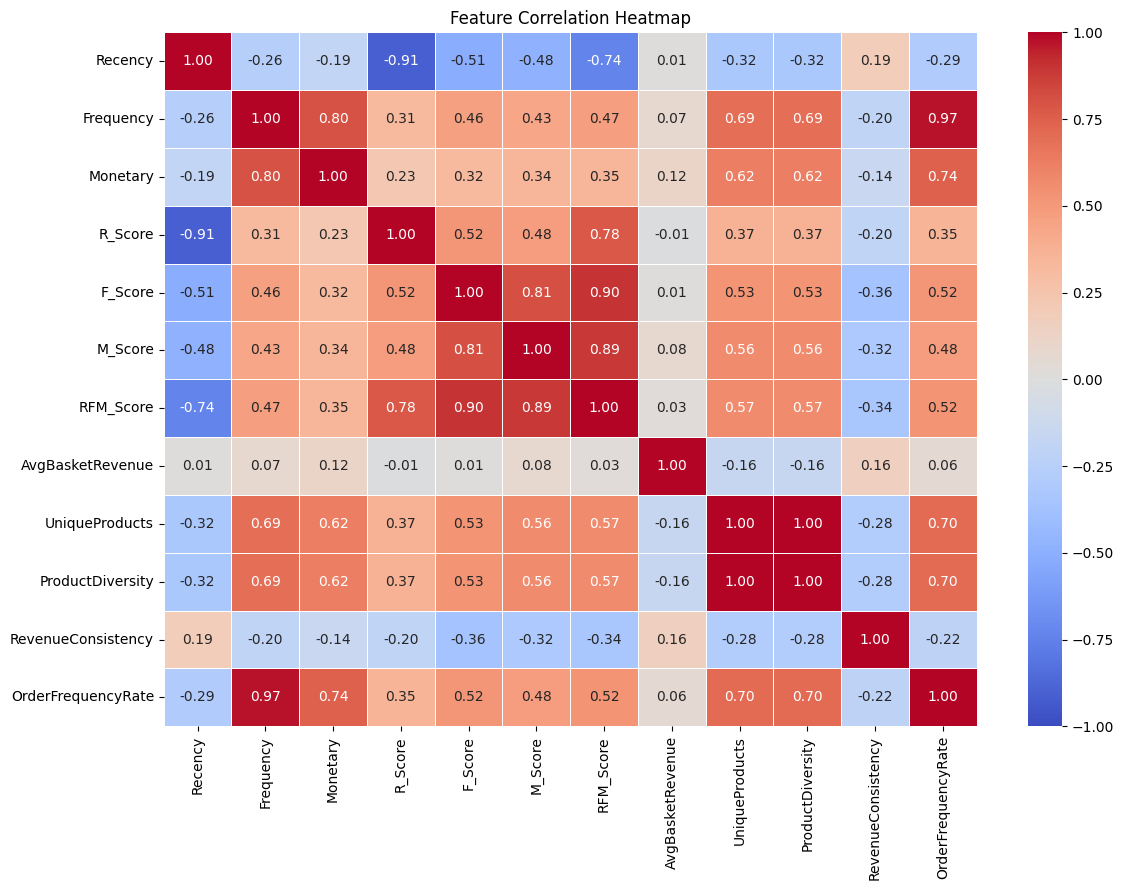

Saved correlation heatmap


In [8]:
# checking correlations between numeric features
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 
                'M_Score', 'RFM_Score', 'AvgBasketRevenue', 'UniqueProducts',
                'ProductDiversity', 'RevenueConsistency', 'OrderFrequencyRate']

corr_matrix = gold_customers[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('data/fig_04_feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved correlation heatmap')

## Step 8 - RFM Distribution Plots

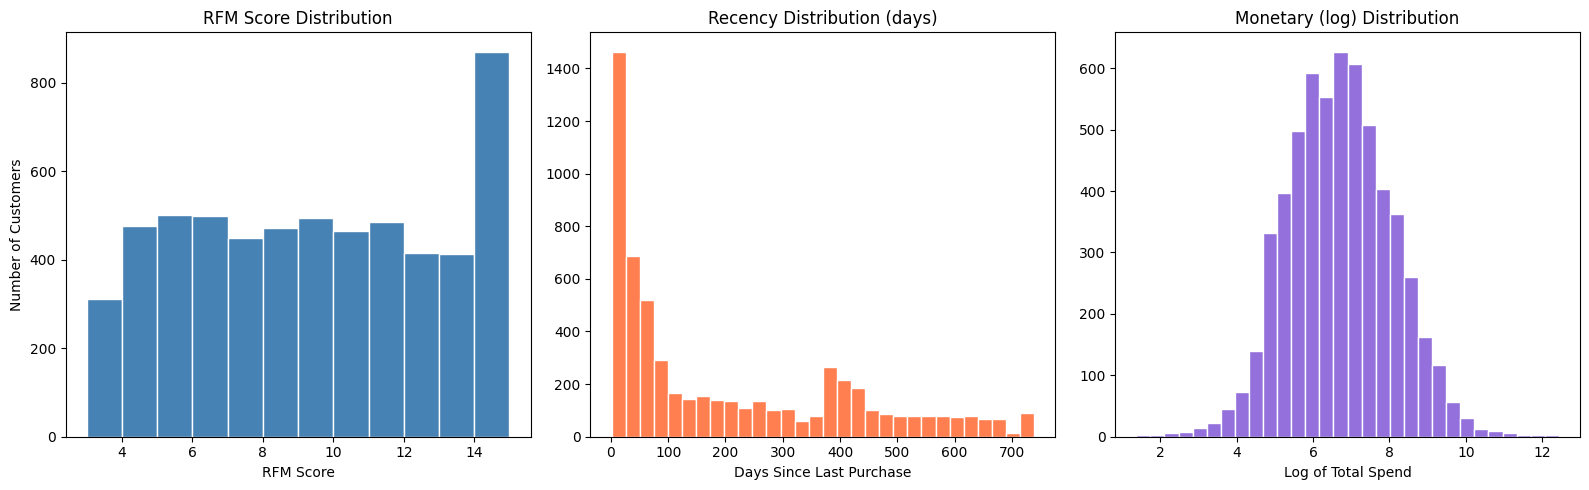

Saved RFM distribution figure


In [9]:
# plotting the distribution of RFM scores
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(gold_customers['RFM_Score'], bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('RFM Score Distribution')
axes[0].set_xlabel('RFM Score')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(gold_customers['Recency'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Recency Distribution (days)')
axes[1].set_xlabel('Days Since Last Purchase')

axes[2].hist(gold_customers['Monetary_Log'], bins=30, color='mediumpurple', edgecolor='white')
axes[2].set_title('Monetary (log) Distribution')
axes[2].set_xlabel('Log of Total Spend')

plt.tight_layout()
plt.savefig('data/fig_05_rfm_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved RFM distribution figure')

## Step 9 - Build SKU Time Series Features for Demand Forecasting

In [10]:
# aggregating daily quantity and revenue per SKU
sku_daily = (df.groupby(['StockCode', pd.Grouper(key='InvoiceDate', freq='D')])
               .agg(DailyQty=('Quantity', 'sum'), DailyRevenue=('Revenue', 'sum'))
               .reset_index())

print('SKU daily shape:', sku_daily.shape)

# filling missing dates with zero for each SKU so time series is continuous
all_dates = pd.date_range(sku_daily['InvoiceDate'].min(), sku_daily['InvoiceDate'].max())
all_skus = sku_daily['StockCode'].unique()

# creating complete grid of SKU x date
idx = pd.MultiIndex.from_product([all_skus, all_dates], names=['StockCode', 'InvoiceDate'])
sku_daily = sku_daily.set_index(['StockCode', 'InvoiceDate']).reindex(idx, fill_value=0).reset_index()

print('After date grid fill shape:', sku_daily.shape)

SKU daily shape: (438051, 4)
After date grid fill shape: (3413441, 4)


In [11]:
sku_daily = sku_daily.sort_values(['StockCode', 'InvoiceDate'])

# lag features
for lag in [1, 7, 14, 30]:
    sku_daily[f'Qty_Lag_{lag}'] = (sku_daily.groupby('StockCode')['DailyQty']
                                              .shift(lag))

# rolling mean features
for window in [7, 14, 30]:
    sku_daily[f'Qty_RollingMean_{window}'] = (sku_daily.groupby('StockCode')['DailyQty']
                                                        .transform(lambda x: x.rolling(window, min_periods=1).mean()))

# rolling std features
for window in [7, 14, 30]:
    sku_daily[f'Qty_RollingStd_{window}'] = (sku_daily.groupby('StockCode')['DailyQty']
                                                       .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0)))

# calendar features
sku_daily['DayOfWeek']  = sku_daily['InvoiceDate'].dt.dayofweek
sku_daily['Month']      = sku_daily['InvoiceDate'].dt.month
sku_daily['WeekOfYear'] = sku_daily['InvoiceDate'].dt.isocalendar().week.astype(int)
sku_daily['IsWeekend']  = (sku_daily['DayOfWeek'] >= 5).astype(int)

print('Lag and rolling features added')
print('SKU time series shape:', sku_daily.shape)

Lag and rolling features added
SKU time series shape: (3413441, 18)


## Step 10 - Save All Feature Tables

In [12]:
# saving customer features
os.makedirs('data', exist_ok=True)

GOLD_CUST_PATH = 'data/gold_customer_features.parquet'
gold_customers.to_parquet(GOLD_CUST_PATH, index=False)
print('Customer features saved:', GOLD_CUST_PATH, '  size:', round(os.path.getsize(GOLD_CUST_PATH)/1e6, 2), 'MB')

# saving sku time series
GOLD_SKU_PATH = 'data/gold_sku_timeseries.parquet'
sku_daily.to_parquet(GOLD_SKU_PATH, index=False)
print('SKU timeseries saved:', GOLD_SKU_PATH, '  size:', round(os.path.getsize(GOLD_SKU_PATH)/1e6, 2), 'MB')

# saving monthly revenue aggregation
monthly_rev = (df.groupby(df['InvoiceDate'].dt.to_period('M'))
               .agg(Revenue=('Revenue', 'sum'),
                    Orders=('Invoice', 'nunique'),
                    Customers=('Customer ID', 'nunique'))
               .reset_index())
monthly_rev['InvoiceDate'] = monthly_rev['InvoiceDate'].astype(str)
monthly_rev['RevenueGrowth'] = monthly_rev['Revenue'].pct_change() * 100

GOLD_MONTHLY_PATH = 'data/gold_monthly_revenue.parquet'
monthly_rev.to_parquet(GOLD_MONTHLY_PATH, index=False)
print('Monthly revenue saved:', GOLD_MONTHLY_PATH)

print()
print('All feature tables saved.')

Customer features saved: data/gold_customer_features.parquet   size: 0.52 MB
SKU timeseries saved: data/gold_sku_timeseries.parquet   size: 29.93 MB
Monthly revenue saved: data/gold_monthly_revenue.parquet

All feature tables saved.
